In [57]:
from src.dataloading.gnndataloader import GNNDataLoader, EpiDataLoader
from src.utils import get_data_env

modelname       = 'gatv2model'
disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epiloader = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epiloader.add_time_features()
epiloader.log_transform_target()
epiloader.set_splits(split_trainval, split_valtest)
epiloader.normalize()
epiloader.add_lagged_features(lags = lags)
epiloader.finalize()

epidata_loader_basis = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

In [58]:
from src.new_models_module.deep.gatv2 import GATv2Model
from src.new_models_module.deep.tgcn import TGCNModel
from src.new_models_module.base.persistencemodel import PersistenceModel

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)


berlin districts removed
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 1 train loss: 0.7363, val loss: 1.2163 ✓ (new best)
Epoch 2 train loss: 0.6832, val loss: 1.0790 ✓ (new best)
Epoch 3 train loss: 0.6523, val loss: 0.9800 ✓ (new best)
Epoch 4 train loss: 0.6353, val loss: 0.9117 ✓ (new best)
Epoch 5 train loss: 0.6204, val loss: 0.8650 ✓ (new best)
Epoch 6 train loss: 0.6136, val loss: 0.8265 ✓ (new best)
Epoch 7 train loss: 0.6044, val loss: 0.7993 ✓ (new best)
Epoch 8 train loss: 0.5977, val loss: 0.7765 ✓ (new best)
Epoch 9 train loss: 0.5958, val loss: 0.7429 ✓ (new best)
Epoch 10 train loss: 0.5878, val loss: 0.7249 ✓ (new best)
Epoch 11 train loss: 0.5799, val loss: 0.6916 ✓ (new best)
Epoch 12 train loss: 0.5721, val loss: 0.6802 ✓ (new best)
Epoch 13 train loss: 0.5694, val loss: 0.6519 ✓ (new best)
Epoch 14 train loss: 0.5624, val loss: 0.6494 ✓ (new best)
Epoch 15 train loss: 0.5638, val loss: 0.6315 ✓ 

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 560.75it/s]

Test loss: 0.8087
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)


berlin districts removed
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 1 train loss: 0.7149, val loss: 1.1781 ✓ (new best)
Epoch 2 train loss: 0.6603, val loss: 1.0124 ✓ (new best)
Epoch 3 train loss: 0.6228, val loss: 0.8931 ✓ (new best)
Epoch 4 train loss: 0.5960, val loss: 0.8163 ✓ (new best)
Epoch 5 train loss: 0.5827, val loss: 0.7626 ✓ (new best)
Epoch 6 train loss: 0.5742, val loss: 0.7330 ✓ (new best)
Epoch 7 train loss: 0.5675, val loss: 0.7122 ✓ (new best)
Epoch 8 train loss: 0.5582, val loss: 0.6928 ✓ (new best)
Epoch 9 train loss: 0.5518, val loss: 0.6826 ✓ (new best)
Epoch 10 train loss: 0.5451, val loss: 0.6743 ✓ (new best)
Epoch 11 train loss: 0.5402, val loss: 0.6719 ✓ (new best)
Epoch 12 train loss: 0.5392, val loss: 0.6689 ✓ (new best)
Epoch 13 train loss: 0.5361, val loss: 0.6682 ✓ (new best)
Epoch 14 train loss: 0.5323, val loss: 0.6639 ✓ (new best)
Epoch 15 train loss: 0.5278, val loss: 0.6567 

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 561.04it/s]

Test loss: 0.7156


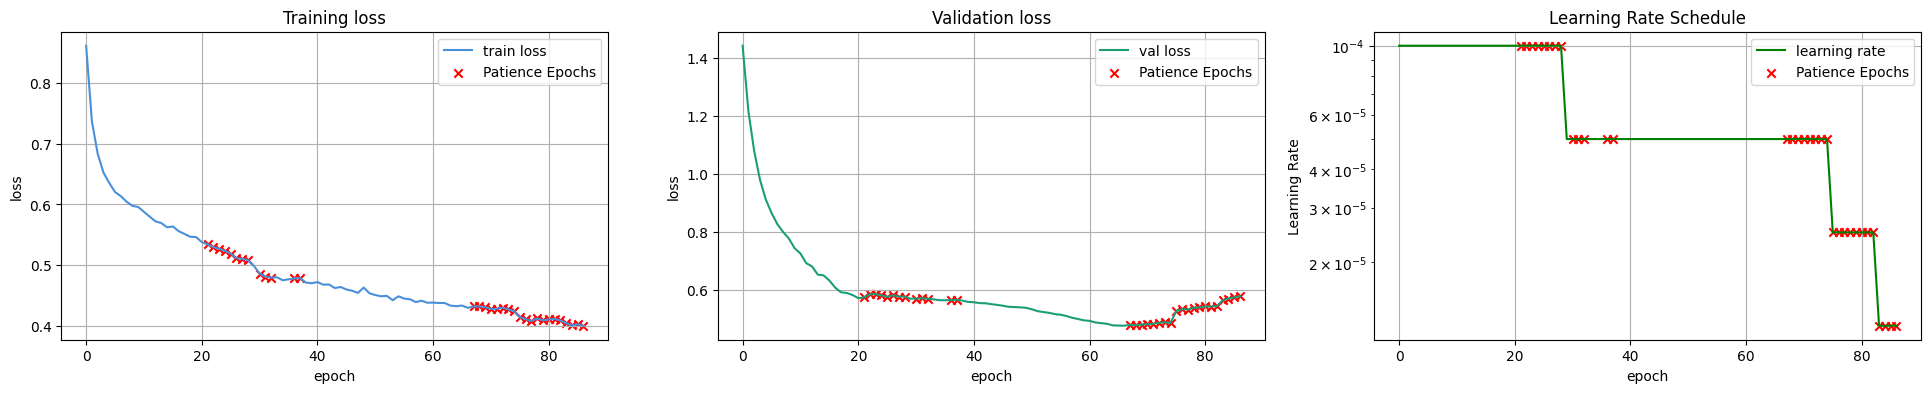

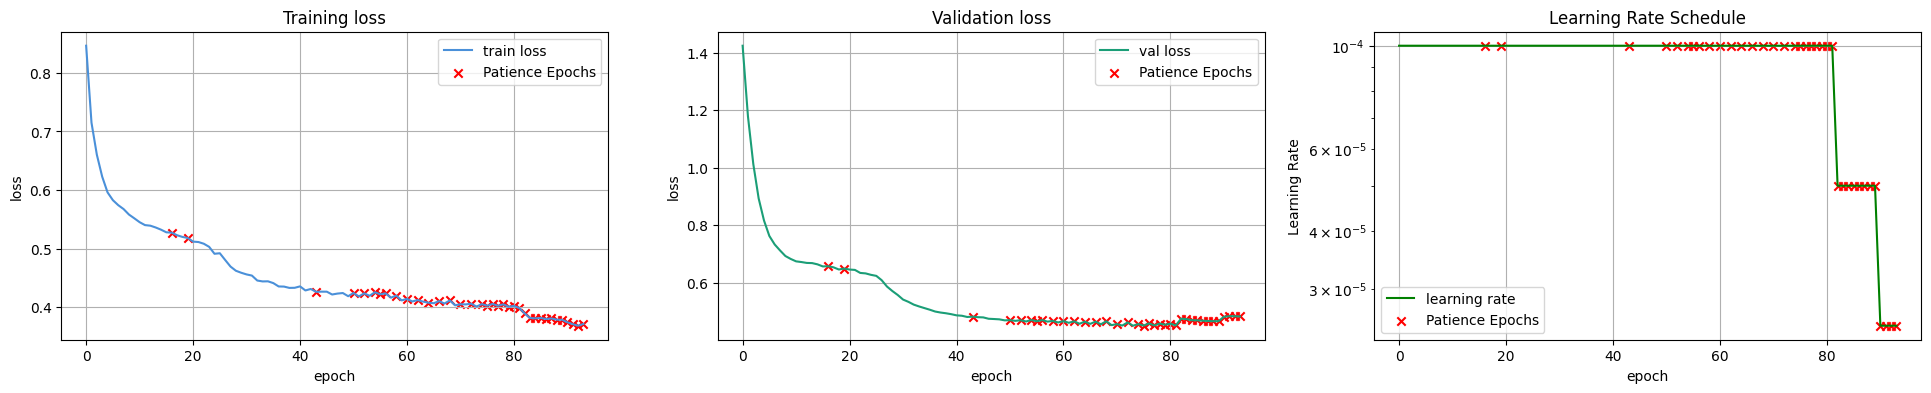

In [59]:
dl_id = epidata_loader_basis.copy().retrieve_graph('identity_selfmax').construct_dataloaders()

gatv2_id = GATv2Model(dataloader= dl_id, name = 'gatv2 id graph')
gatv2_id.set_model_hparams()
gatv2_id.set_global_hparams(**global_hparams)
gatv2_id.train(2)
gatv2_id.forecast('test')

dl_bn = epidata_loader_basis.copy().retrieve_graph('boolean_neighbors_selfmean').construct_dataloaders()

gatv2_bn = GATv2Model(dataloader= dl_bn, name = 'gatv2 bn graph')
gatv2_bn.set_model_hparams()
gatv2_bn.set_global_hparams(**global_hparams)
gatv2_bn.train(2)
gatv2_bn.forecast('test')

baseline = PersistenceModel(epiloader)
baseline.forecast('test')

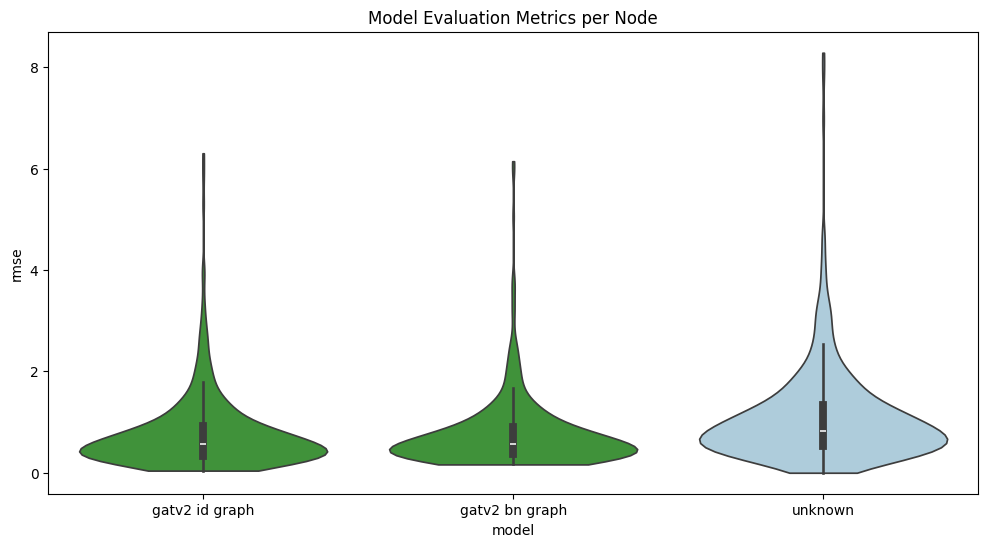

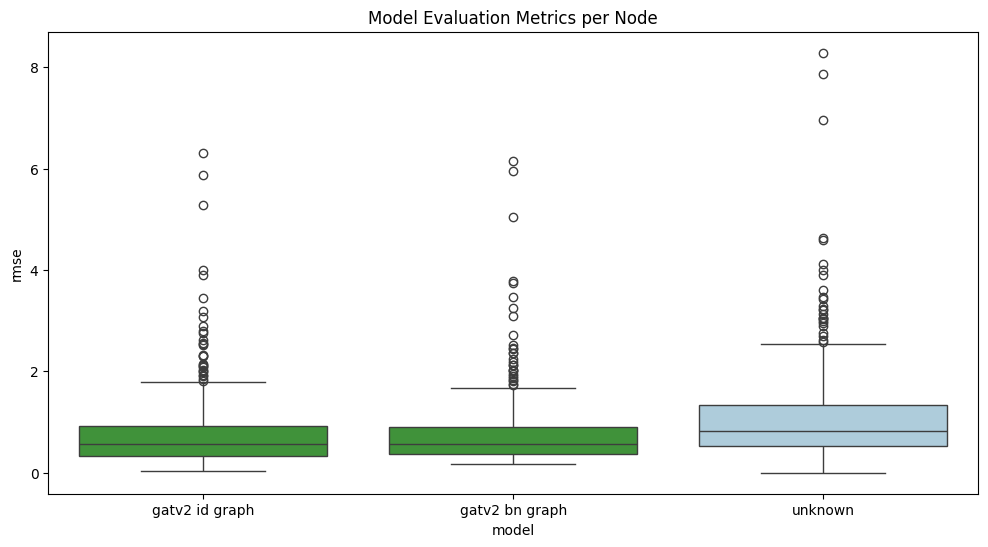

In [66]:

evaling = Evaluator([gatv2_id, gatv2_bn, baseline])
evaling.add_evaluation()
evaling.plot_metric('rmse')
evaling.plot_metric('rmse',plot_type='box')